In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.weightstats import DescrStatsW
import matplotlib.patches as patches

plt.style.use('seaborn-v0_8')

In [2]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


In [9]:
breaks = [0.25, 0.5, 0.75, 0.85, 0.9, 0.94, 0.96, 0.97, 0.98, 0.99]
ages = list(range(data.AGEP.min(), data.AGEP.max() + 1))
quantiles = []
binwidth = 2_000
bincounts = []

for index in ages:
    subset = data[data.AGEP == index]
    subset = subset.sort_values('inc2024')
    d = DescrStatsW(subset.inc2024, weights=subset.PWGTP)
    quantiles.append(d.quantile(breaks))
    bincount = {}
    for _, row in subset.iterrows():
        bin_index = row.inc2024 // binwidth
        bincount[bin_index] = bincount.get(bin_index, 0) + row.PWGTP
    bincounts.append(bincount)

results = np.stack(quantiles)

In [10]:
max(bincounts[0].values())

287000

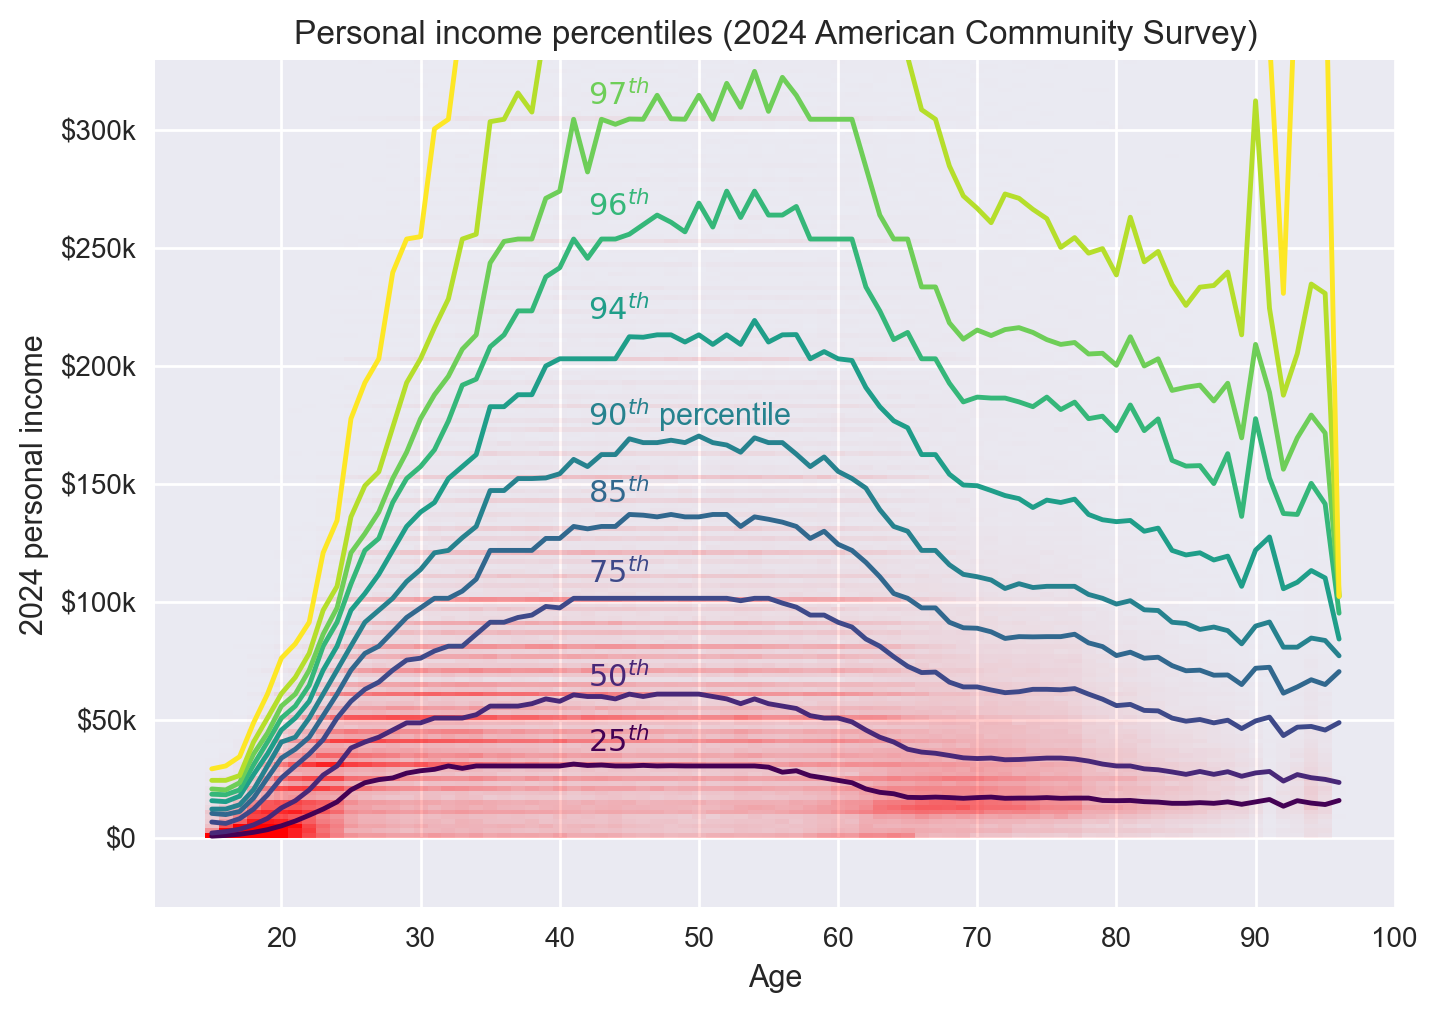

In [21]:
cmap = plt.get_cmap('viridis')  # 'viridis', 'plasma', 'cividis', etc.
colors = cmap(np.linspace(0, 1, len(breaks)))

for index, series in enumerate(results.T):
    plt.plot(ages, series, color=colors[index])  # '-o', markersize=4, 
    if (series[40] + series[41]) / 2 < 330_000:
        plt.text(
            y=(series[40] + series[41]) / 2 + {0.25: 12_000, 0.5: 12_000, 0.75: 12_000, 0.85: 12_000, 
                                               0.9: 12_000, 0.94: 12_000, 0.96: 4_000, 0.97: 0, 0.98: 0, 0.99: 0}[breaks[index]],
            x=42,
            s=f'${int(breaks[index]*100)}^{{th}}$' if breaks[index] != 0.9 else f'${int(breaks[index]*100)}^{{th}}$ percentile',
            ha='left', va='center',
            color=colors[index], fontsize=11
        )

bottom, top = plt.ylim()
plt.ylim(top=300_000 - bottom)  # bottom is negative
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k' if x != 0 else '$0'))
plt.ylabel('2024 personal income')
plt.xlabel('Age')
plt.title('Personal income percentiles (2024 American Community Survey)')

for age, counts in zip(ages, bincounts):
    maxcount = sorted(counts.values())[-1]
    maxcount = max(bincounts[0].values())  # override...
    for key, value in counts.items():
        rect = patches.Rectangle(
            (age - 0.5, key * binwidth),          # bottom-left corner
            1, binwidth,   # dimensions
            linewidth=1,
            edgecolor='none',
            facecolor='red',
            alpha=min(1.0, (value / maxcount))         # opacity: 0.0 = transparent, 1.0 = opaque
            )
        plt.gca().add_patch(rect)

plt.show()